[np.float64(2.753016685807562), np.float64(3.0838776409160427), np.float64(5.506033371615124), np.float64(6.167755281832085)]
[np.float64(2.1491150947184603), np.float64(1.3471568273157966), np.float64(4.298230189436921), np.float64(2.694313654631593)]
[np.float64(1.2810001160818305), np.float64(2.2891749337459495), np.float64(1.2810001160818305), np.float64(2.2891749337459495)]


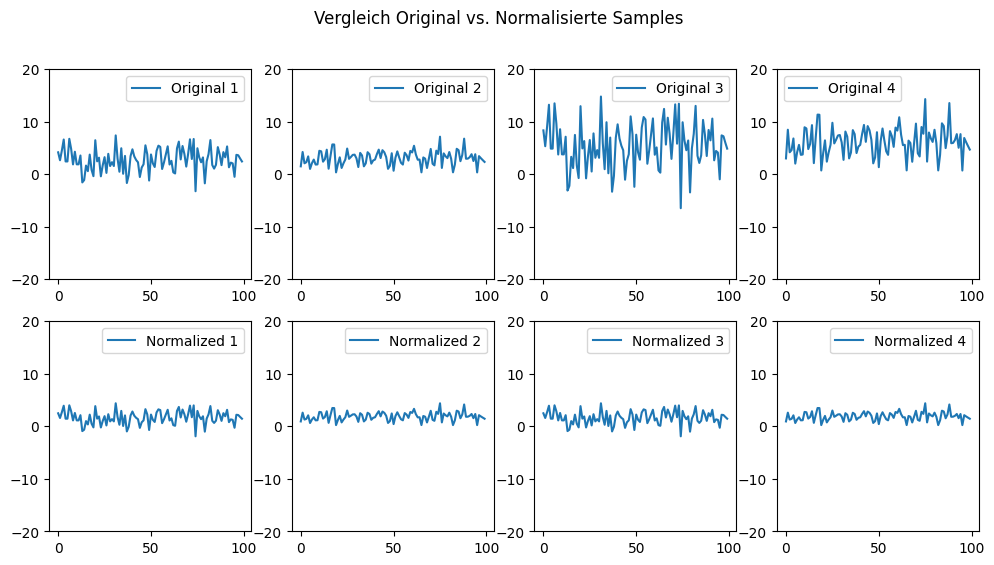

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Beispiel: Erstellen von 5 Samples mit zufälligen Werten (positive und negative)
np.random.seed(42)
num_samples = 4
num_points = 100

# Erstellen von zufälligen Daten mit unterschiedlichen Amplituden
samples = [(np.random.randn(num_points) * np.random.uniform(0.5, 5.0) + np.random.randint(3, 5)) for _ in range(num_samples // 2)]

samples.append(samples[0] * 2)
samples.append(samples[1] * 2)

y_min = -20
y_max = 20

print(
    [np.mean(e) for e in samples]
)


print([
    np.std(sample) for sample in samples
])

# 1. Lokale Z-Normalisierung pro Sample
normalized_samples = [(sample) / np.std(sample) for sample in samples]

print(
    [np.mean(e) for e in normalized_samples]
)


# 2. Globale Skalierung anhand der mittleren Amplitude (Max-Wert pro Sample als Amplitudenmaß)
global_amplitude = np.mean([np.max(np.abs(sample)) for sample in normalized_samples])
scaled_samples = [sample * (global_amplitude / np.max(np.abs(sample))) for sample in normalized_samples]

# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 6))

for i, (orig, norm) in enumerate(zip(samples, scaled_samples)):
    plt.subplot(2, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}", )
    plt.ylim(y_min, y_max)

    plt.legend()
    
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(norm, label=f"Normalized {i+1}")
    plt.ylim(y_min, y_max)
    plt.legend()

plt.suptitle("Vergleich Original vs. Normalisierte Samples")
plt.show()

In [3]:
print(np.mean(samples))

0.05588297248132735


[np.float64(2.776841363045758), np.float64(3.074690064811456), np.float64(5.553682726091516), np.float64(6.149380129622912)]
4.388648570892911
[np.float64(0.6327326779963118), np.float64(0.7006006553370215), np.float64(1.2654653559926237), np.float64(1.401201310674043)]


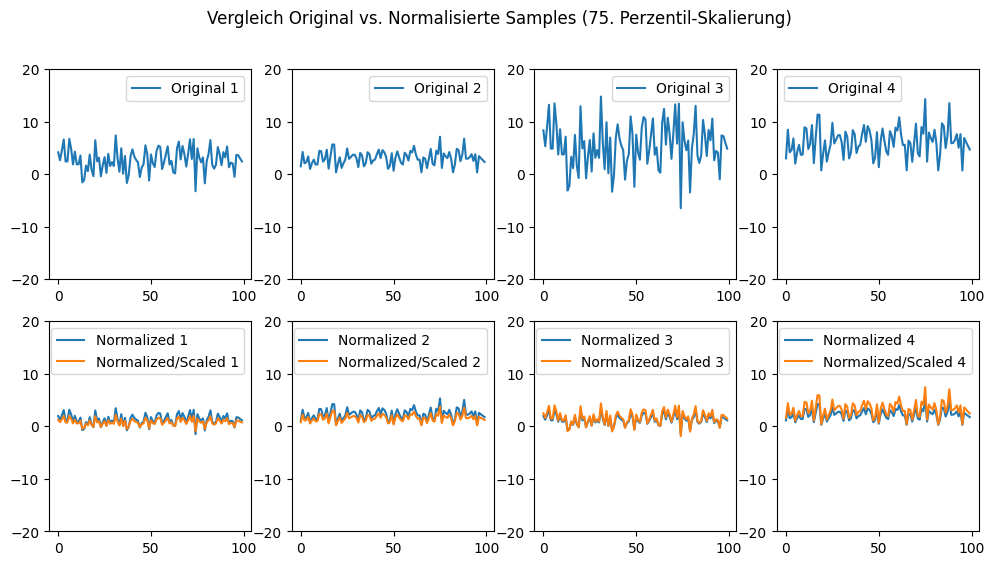

In [7]:


percentile = 50

# 2. Globale Skalierung anhand des 75. Perzentils pro Sample
global_amplitude = np.mean([np.percentile(np.abs(sample), percentile) for sample in samples])
# global_amplitude = np.mean(samples)

print([np.percentile(np.abs(sample), percentile) for sample in samples])
print(global_amplitude)
print([(np.percentile(np.abs(sample), percentile)/global_amplitude) for sample in samples])
scaled_samples = np.array([normalized_samples[s_i] * (np.percentile(np.abs(sample), percentile)/global_amplitude ) for s_i, sample in enumerate(samples)])

# Bestimmen der gemeinsamen y-Limits für eine einheitliche Skalierung


# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 6))

for i, (orig, norm, scaled) in enumerate(zip(samples, normalized_samples, scaled_samples)):
    plt.subplot(2, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()

    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(norm, label=f"Normalized {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()
    
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(scaled, label=f"Normalized/Scaled {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()

plt.suptitle("Vergleich Original vs. Normalisierte Samples (75. Perzentil-Skalierung)")
plt.show()

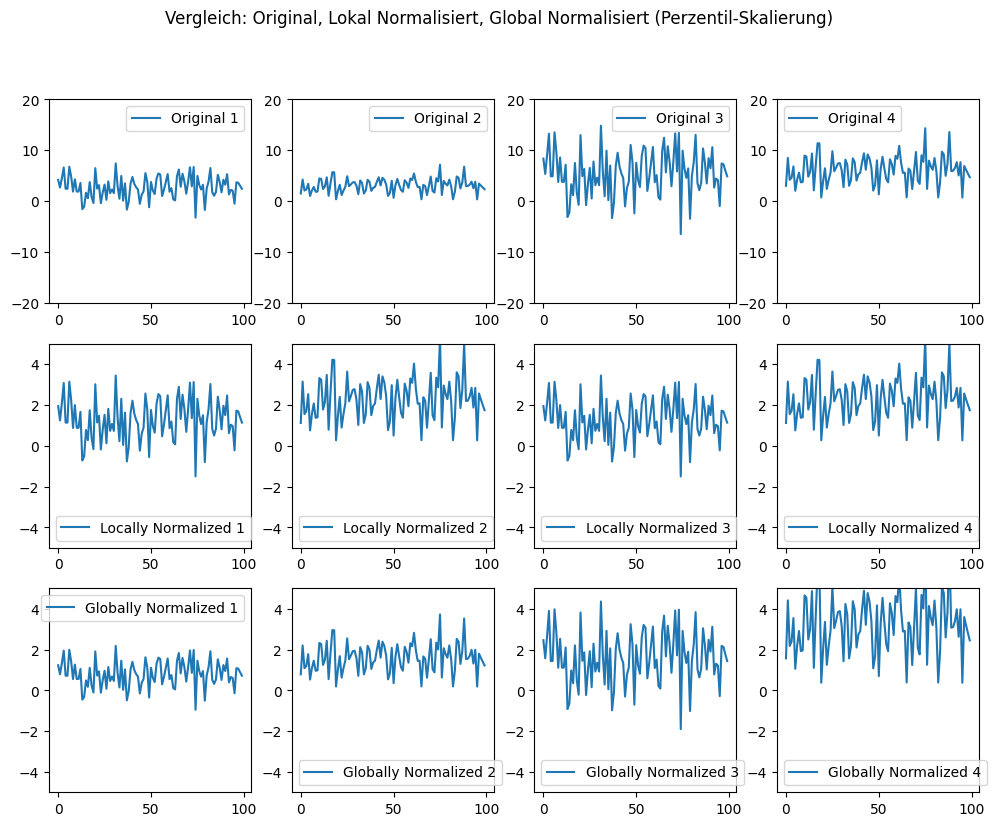

In [8]:
# Visualisierung der Daten vor und nach der Normalisierung
plt.figure(figsize=(12, 9))

for i, (orig, norm_local, norm_global) in enumerate(zip(samples, normalized_samples, scaled_samples)):
    plt.subplot(3, num_samples, i + 1)
    plt.plot(orig, label=f"Original {i+1}")
    plt.ylim(y_min, y_max)  # Einheitliche y-Limits setzen
    plt.legend()
    
    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.plot(norm_local, label=f"Locally Normalized {i+1}")
    plt.ylim(-5, 5)  # Einheitliche y-Limits setzen
    plt.legend()

    plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
    plt.plot(norm_global, label=f"Globally Normalized {i+1}")
    plt.ylim(-5, 5)  # Einheitliche y-Limits setzen
    plt.legend()

plt.suptitle("Vergleich: Original, Lokal Normalisiert, Global Normalisiert (Perzentil-Skalierung)")
plt.show()
